In [17]:
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import colorsys
from typing import Dict, List
import numpy as np

import pickle
import os
# BASE_DIR = "/capstor/store/cscs/swissai/infra01/apertus_probes"
BASE_DIR = "/iopsstor/scratch/cscs/astepancic/mera-runs"

In [3]:
DATASET_NAMES = ["mmlu_high_school", "mmlu_professional", "ARC-Challenge", "ARC-Easy", "sms_spam"]
DATASET_TITLES = ["MMLU High School", "MMLU Professional", "ARC Challenge", "ARC Easy", "SMS Spam"]
MODEL_NAMES = ["Apertus-8B-Instruct-2509", "Llama-3.1-8B-Instruct"]
INDEX = 0

In [7]:
model = MODEL_NAMES[1]
dataset = DATASET_NAMES[INDEX]

path = os.path.join(BASE_DIR, dataset, model, "acts.pkl") 
def load_pkl(path): 
    with open(path, "rb") as f:
        return pickle.load(f)
    
acts = load_pkl(path)
print(acts.keys())

activations = acts["activations_cache"]
y_error_sm = acts["y_error_sm"]


dict_keys(['activations_cache', 'y_correct', 'y_error_sm', 'y_error_ce', 'activations_cache_exact', 'y_correct_exact', 'y_error_sm_exact', 'y_error_ce_exact'])


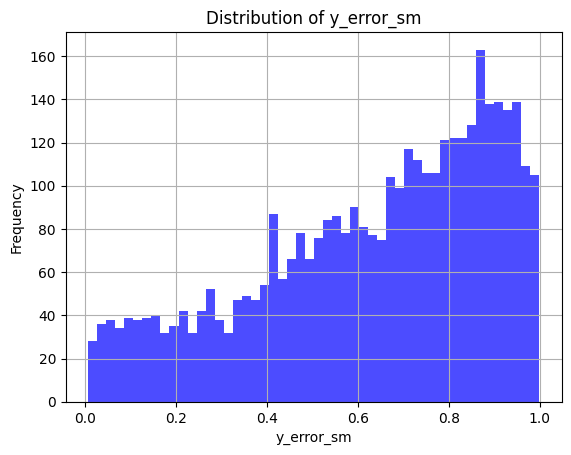

In [ ]:
plt.hist(y_error_sm, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of y_error_sm')
plt.xlabel('y_error_sm')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Confusion Matrix for Correctness
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Get y_correct from acts
y_correct = acts["y_correct"]

# Create predictions based on error threshold
# Low error (< 0.5) predicts correct, high error (>= 0.5) predicts incorrect
# This is a simple heuristic - you can adjust the threshold
error_threshold = 0.5
y_pred = (y_error_sm < error_threshold).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_correct, y_pred, labels=[0, 1])

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Incorrect', 'Correct'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix for Correctness\n(Threshold: error < {error_threshold})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print statistics
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp
accuracy = (tp + tn) / total if total > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nConfusion Matrix Statistics:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

In [ ]:
def compute_layer_norms(activations_dict):
    """
    Compute L2 norms for each layer and each sample.
    
    Args:
        activations_dict: Dict mapping layer_idx -> array of shape (n_samples, n_features)
    
    Returns:
        norms_by_layer: Dict mapping layer_idx -> array of norms (n_samples,)
        stats_df: DataFrame with statistics per layer
    """
    norms_by_layer = {}
    stats_list = []
    
    for layer_idx, layer_activations in activations_dict.items():
        # Compute L2 norm for each sample: sqrt(sum(x_i^2))
        sample_norms = np.linalg.norm(layer_activations, axis=1)
        norms_by_layer[layer_idx] = sample_norms
        
        # Compute statistics
        stats_list.append({
            'Layer': layer_idx,
            'Mean': np.mean(sample_norms),
            'Std': np.std(sample_norms),
            'Median': np.median(sample_norms),
            'Min': np.min(sample_norms),
            'Max': np.max(sample_norms),
            'Q25': np.percentile(sample_norms, 25),
            'Q75': np.percentile(sample_norms, 75),
        })
    stats_df = pd.DataFrame(stats_list)
    return norms_by_layer, stats_df


(3860, 4096)


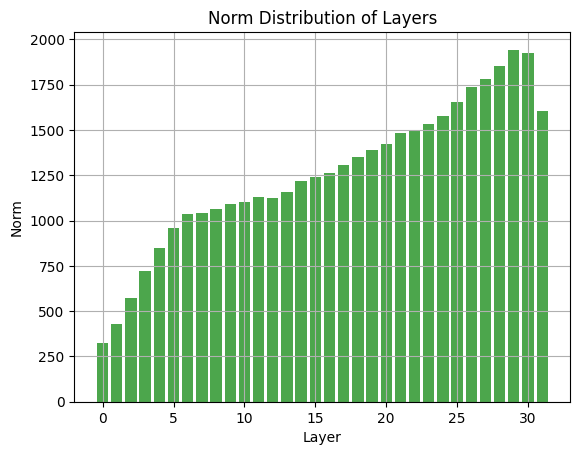

In [16]:
import numpy as np

# Calculate the norm for each layer
print(activations[0].shape)
# Plot the norm distribution
plt.bar(layer_norms.keys(), layer_norms.values(), color='green', alpha=0.7)
plt.title('Norm Distribution of Layers')
plt.xlabel('Layer')
plt.ylabel('Norm')
plt.grid(True)
plt.show()